# Amount invested vs effective yield

This notebook builds a **table** and a **line chart** showing how **effective yield** (portfolio annualized return from the optimizer) changes as the **total amount invested** increases, using the sample institutions from `data/sample1.yaml`.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os

import matplotlib.pyplot as plt
import pandas as pd

from rate_allocator import allocate
from rate_allocator.adapters.yaml_loader import load_institutions_from_yaml

if os.path.basename(os.getcwd()) == "notebooks":
    data_file = "../data/sample1.yaml"
else:
    data_file = "data/sample1.yaml"

institutions = load_institutions_from_yaml(data_file)
print(f"Loaded {len(institutions)} institutions from {data_file}")

Loaded 6 institutions from ../data/sample1.yaml


## Sweep total investment and collect effective yield

`result.effective_rate` is the portfolio’s **effective annual yield** for the chosen horizon (here 1 year, 365 periods).

In [9]:
# list from 1 to 10 in steps of 0.5
#tiers = [i / 2 for i in range(1_000, 1_000_000, 500)]
#print(f"Tiers: {tiers}")

In [10]:
amounts = [10_000, 25_000, 50_000, 100_000, 250_000, 500_000, 750_000, 1_000_000]
horizon_years = 1.0
periods_per_year = 365

rows = []
for amt in amounts:
    result = allocate(
        total=amt,
        institutions=institutions,
        horizon_years=horizon_years,
        periods_per_year=periods_per_year,
    )
    rows.append(
        {
            "amount_invested": amt,
            "effective_yield": result.effective_rate,
            "expected_return": result.expected_return,
        }
    )

df = pd.DataFrame(rows)

display_df = df.assign(
    amount_invested=df["amount_invested"].map(lambda x: f"${x:,}"),
    effective_yield=df["effective_yield"].map(lambda x: f"{x:.2%}"),
    expected_return=df["expected_return"].map(lambda x: f"${x:,.2f}"),
)
print("Amount invested vs effective yield\n")
print(display_df.to_string(index=False))

Amount invested vs effective yield

amount_invested effective_yield expected_return
        $10,000          28.17%       $2,817.39
        $25,000          28.17%       $7,043.48
        $50,000          21.00%      $10,501.53
       $100,000          17.05%      $17,054.26
       $250,000          13.10%      $32,742.50
       $500,000          11.78%      $58,889.57
       $750,000          11.15%      $83,658.56
     $1,000,000          10.98%     $109,805.63


## Chart: x = amount invested, y = effective yield

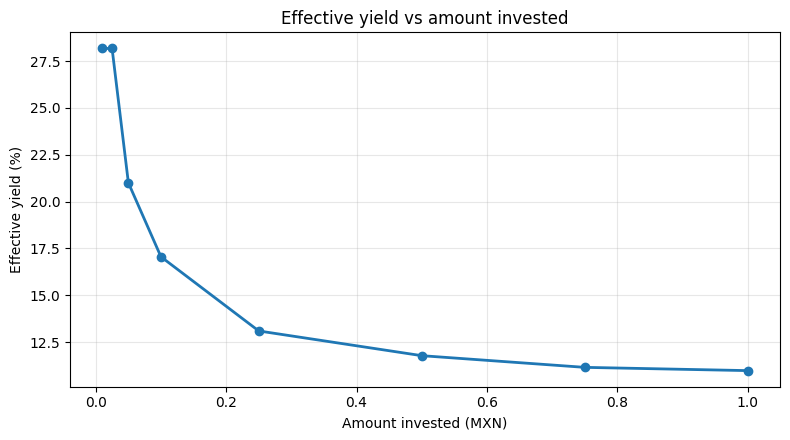

In [16]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(
    df["amount_invested"] * 1e-6,
    df["effective_yield"] * 100,
    marker="o",
    linewidth=2,
)
ax.set_xlabel("Amount invested (MXN)")
ax.set_ylabel("Effective yield (%)")
ax.set_title("Effective yield vs amount invested")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()